[0.9998933249998118, 0.99990292257196, 0.99990292257196, 0.999883352914391, 0.9998929504865395, 0.9998828381146219, 0.9998976918020783, 0.9998951091493773, 0.9998951091493773, 0.9998859102216657, 0.9998976918020783, 0.999883352914391, 0.9998976918020783, 0.9998929504865395, 0.99990292257196, 0.999883352914391, 0.9999003652646852, 0.9998929504865395, 0.999883352914391, 0.999882838114622, 0.99990292257196, 0.9998951091493773, 0.9998976918020783, 0.999903437371729, 0.999903437371729, 0.9998859102216656, 0.9999003652646852, 0.9998951091493773, 0.9998976918020783, 0.9999003652646852, 0.9998976918020783, 0.9998976918020783]
Generation 1: Best fitness = 0.2.
[1.1998828381146218, 1.199882838114622, 1.199883352914391, 1.199883352914391, 1.1998951091493772, 0.2, 1.1998951091493772, 1.1998833529143909, 0.2, 1.1998929504865392, 1.1998929504865392, 1.199883352914391, 0.2, 0.2, 0.2, 0.2, 1.1999003652646854, 1.1999003652646854, 1.19990292257196, 0.2, 0.2, 1.1998933249998118, 0.2, 0.2, 0.2, 0.2, 0.2, 

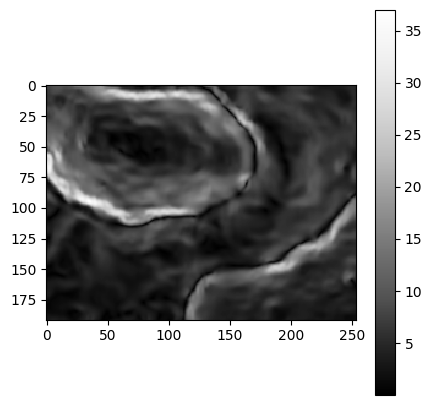

Population size = 64
Generation 0: Best fitness = 0.6598188104545131.
Generation 1: Best fitness = 0.6693753985720291.
Generation 2: Best fitness = 0.6693753985720291.
Generation 3: Best fitness = 0.6693753985720291.
Generation 4: Best fitness = 0.6693753985720291.
Generation 5: Best fitness = 0.6693753985720291.


KeyboardInterrupt: 

In [1]:
import numpy as np
import rasterio as rio
from rasterio.plot import show
import matplotlib.pyplot as plt
from time import perf_counter
import pandas as pd
import elevation 
import random
import copy
import datetime
import BORAS_v1
import itertools
import math

waypoints = list([(53,53),(80,345),(234,253),(347,56),(125,190)])
mean_speed =0.0225
pop_size = 32
max_generations = 20
filename = "data/dems/lunargem_4to5_slope.tif"

class path_info:
        def __init__(self,name,eu_fit,r_fit,bpath,t_trav):
            self.name = name
            self.eu_fit = eu_fit
            self.r_fit = r_fit
            self.bpath = bpath
            self.t_trav = t_trav

def crossover3(parent1,parent2,crossover_rate=0.9):
    if random.random()< crossover_rate:
            crossover_point= random.randint(0,(len(parent1)-1))
            child = parent1[:crossover_point]+(parent2[crossover_point:])
            return child
    else:
        return parent1
    
def mutation2(path, mutation_rate=0.5):
    if random.random()< mutation_rate:
            mutation_point1= random.randint(0,(len(path)-1))
            mutation_point2= random.randint(0,(len(path)-1))
            place_holder = path[mutation_point1]
            path[mutation_point1] = path[mutation_point2]
            path[mutation_point2] = place_holder
    return path
   
order = list(np.arange((len(waypoints))))    


permutations = list(itertools.permutations(order,r=2))
info_paths = []
total_t_time = 0
max_min = False
for i in range(len(permutations)):
    start = waypoints[permutations[i][0]]
    end = waypoints[permutations[i][1]]
    distance=np.sqrt((start[0]-end[0])**2 + (start[1]-end[1])**2)
    t_time = distance/mean_speed
    fit = (1-(1/t_time))
    info_paths.append(path_info(permutations[i],fit,0,[],[]))

def tsp(waypoints,pop_size,max_generations):
    generations = 0 
    pop = []
    fitness = []
    for indv in range(pop_size):
        random.shuffle(order)
        populant = copy.deepcopy(order)
        pop.append(populant)
        total_fit = 0
        for i in range(len(waypoints)):
            idx_perm = permutations.index((order[(i-1)],order[i]))
            if info_paths[idx_perm].r_fit == 0:
                fit = info_paths[idx_perm].eu_fit
            else:
                fit = info_paths[idx_perm].r_fit
            total_fit = total_fit + fit
        fitness.append((total_fit/len(waypoints)))

    while not BORAS_v1.termination_condition(generations,max_generations):
        generations += 1
        next_gen = []

        #SELECT POPULATION FOR NEXT GEN
        selected_pop_size = int(pop_size/8)
        select_fitness = copy.deepcopy(fitness)
        print(select_fitness)
        pop_w_elite = copy.deepcopy(pop)
        elite_pop = BORAS_v1.select_pop_max(pop,select_fitness, pop_size,max_min, num_to_select=selected_pop_size)
        select_fitness = copy.deepcopy(fitness)
        selected_pop = BORAS_v1.select_pop_rand(pop_w_elite,select_fitness, pop_size, selected_pop_size*7)
        selected_pop = selected_pop +  elite_pop
        
        pop_indexes = list(np.arange(0,pop_size,1,dtype=int))

        #ELITE
        for i in range(selected_pop_size):
            next_gen.append(elite_pop[i])


        pop_indexes = list(np.arange(0,( selected_pop_size*7),1,dtype=int))
        random.shuffle(selected_pop)
        for _ in range(0, ( selected_pop_size*7),2):
                    i,j = random.sample(pop_indexes,k=2)
                    pop_indexes.remove(i)
                    pop_indexes.remove(j)
                    parent1 =[]
                    parent2=[]
                    child1=[]
                    child2=[]
                    parent1 , parent2 = selected_pop[i],selected_pop[j]
                    child1,child2 = crossover3(parent1,parent2), crossover3(parent2,parent1)
                    #MUTATION
                    child1,child2 = BORAS_v1.mutation2(child1),BORAS_v1.mutation2(child2)
                    next_gen.append(child1)
                    next_gen.append(child2)

        pop[:] = next_gen
        fitness = []

        for path in pop:
            total_fit = 10
            for i in range(len(path)):
                if path[(i-1)] == path[i]:
                    total_fit = 1
                else:
                    idx_perm = permutations.index((path[(i-1)],path[i]))
                    if info_paths[idx_perm].r_fit == 0:
                        fit = info_paths[idx_perm].eu_fit
                    else:
                        fit = info_paths[idx_perm].r_fit
                    total_fit = total_fit + fit
                nd_path = list(set(path))
                if len(nd_path)!= len(path):
                    total_fit = 1
            fitness.append((total_fit/len(path)))       
        best_fitness = min(fitness)
        best_path_idx = fitness.index(best_fitness)
        print(f'Generation {generations}: Best fitness = {best_fitness}.')
        best_path = pop[best_path_idx]
    return best_path, best_fitness
        
best_path, best_fitness = tsp(waypoints,pop_size,max_generations)
print('Best path found:',best_path)
old_best_fitness = 1

while old_best_fitness != best_fitness:
    #if old_best_fitness == 0:
        # best_path = [0,1,2,3,4]
    old_best_fitness = best_fitness
    for i in range(len(best_path)):
        idx_perm = permutations.index((best_path[(i-1)],best_path[i]))
        if info_paths[idx_perm].r_fit == 0:
            dem_c = []
            start = waypoints[best_path[(i-1)]]
            end = waypoints[best_path[i]]
            BORAS_v1.crop_grid(start,end,filename)
            dem_c = rio.open("crop-file")
            dem_array = dem_c.read(1).astype('float64')
            fig2, ax = plt.subplots(1, figsize=(5, 5))
            plt.imshow(dem_array, cmap='Greys_r',interpolation='none')
            plt.colorbar()
            plt.axis("on")
            plt.show()
            new_start, new_end = BORAS_v1.new_start_end(start,end,dem_c)
            bfit_ga_path,fitnesses_gen,traverse_time,best_ga_path = BORAS_v1.ga(new_start,new_end,dem_c)
            fit = (1-(1/t_time))
            info_paths[idx_perm].r_fit = fit
            best_ga_path_trans = BORAS_v1.translate_back_to_original(start, end, best_ga_path)
            info_paths[idx_perm].bpath = best_ga_path_trans
            info_paths[idx_perm].t_trav = traverse_time
            dem_c.close()
    best_path, best_fitness = tsp(waypoints,pop_size,max_generations)
    print('Best path found:',best_path)
    

#best_path = tsp(waypoints,mean_speed,pop_size,max_generations)
#print(best_path)

In [ ]:
import matplotlib.cm as cm
#best_path = [0,1,2,3,4]
dem = rio.open(filename)
slope_dem =dem.read(1)
color = iter(cm.rainbow(np.linspace(0, 1, len(best_path))))
fig, ax = plt.subplots(1, figsize=(5, 5))
ax.imshow(slope_dem, origin='upper', cmap='Greys_r', interpolation='none')
total_trav_time = 0
for i in range(len(best_path)):
    trav_time = 0
    idx_perm = permutations.index((best_path[(i-1)],best_path[i]))
    best_ga_path = info_paths[idx_perm].bpath
    #trav_time = info_paths[idx_perm].t_trav
    #total_trav_time =  total_trav_time + trav_time
            # Extract x, y coordinates for path plotting
    path_x = [point[1] for point in best_ga_path]  # Col indices
    path_y = [point[0] for point in best_ga_path]  # Row indices
        # Plot path
    c = next(color)
    plt.plot(path_x, path_y, marker='o', color=c, markersize=1, linewidth=0.5)

plt.title('Shortest Route Through the Waypoints')
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.grid(False)
plt.show()
print(total_trav_time)